# Compare Inversion Calls Across Treatments
What would be interesting to see is the inversion-calling performance in linked reads across inversion sizes and depths. Since we already created the assessment tables from the individual size-class data exploration, we can read those in without having to reprocess those data.

In [3]:
library(ggplot2)
library(dplyr)
options(warn = -1, repr.plot.width = 19, repr.plot.height = 12)

In [ ]:
list.files("assess_called_sv")

[1] "large.sv.assessment"  "medium.sv.assessment" "small.sv.assessment" 
[4] "xl.sv.assessment"

In [4]:
assess <- Reduce(rbind, Map(function(x) {read.csv(x, header = T)}, list.files("assess_called_sv", full.names = T)))

# remove unnecessary columns
assess <- assess[, c(1, 6:11)]
assess$depth <- as.factor(assess$depth)
assess$size <- factor(assess$size, ordered = T, levels = c("small","medium","large","xl"))

head(assess, 10)

,contig,sample,size,simulated,zygosity,state,depth
,<chr>,<chr>,<ord>,<lgl>,<chr>,<chr>,<fct>
1,2L,pooled,large,TRUE,hom,true positive,0.5
2,2L,sample_01,large,TRUE,hom,false negative,0.5
3,2L,sample_02,large,TRUE,hom,false negative,0.5
4,2L,sample_03,large,TRUE,hom,false negative,0.5
5,2L,sample_04,large,TRUE,hom,false negative,0.5
6,2L,sample_05,large,TRUE,hom,false negative,0.5
7,2L,sample_06,large,TRUE,hom,false negative,0.5
8,2L,sample_07,large,TRUE,hom,false negative,0.5
9,2L,sample_08,large,TRUE,hom,false negative,0.5


## Sample-level Calling
### Prepare the Data
It would probably make sense to collapse these data somewhat to show a representation of true positives vs false negatives (as a ratio) across depths (x axis) and faceted for hom/het in the non-pooled data. We will also remove inversions that weren't simulated for a sample b/c we aren't interested in true negatives (since there were no false positives).

In [72]:
samples <- assess[assess$sample != "pooled" & assess$simulated,]

samples <- group_by(samples, size, depth, zygosity, state) %>%
    summarize(count = n())

head(samples)

`summarise()` has grouped output by 'size', 'depth', 'zygosity'. You can
override using the `.groups` argument.


size,depth,zygosity,state,count
<ord>,<fct>,<chr>,<chr>,<int>
small,0.5,het,false negative,72
small,0.5,het,true positive,2
small,0.5,hom,false negative,68
small,0.5,hom,true positive,1
small,2,het,false negative,60
small,2,het,true positive,14


Some of the treatments don't have true positives or false negatives, so we'll need to add in rows with count `0` for those treatments.

In [73]:
# add missing rows with value 0 in the event there were no true positives or false negatives for a treatment
# instantiate empty def
missings <- samples[0,]

for(size in c("small","medium","large","xl")){
    for(depth in levels(samples$depth)){
        for(zyg in c("hom","het")){
            .df <- samples[samples$size == size & samples$depth == depth & samples$zygosity == zyg,]
            if(!("false negative" %in% .df$state)){
                missings[nrow(missings)+1,] <- list(size, depth, zyg,"false negative", 0)
            }
            if(!("true positive" %in% .df$state)){
                missings[nrow(missings)+1,] <- list(size, depth, zyg,"true positive", 0)
            }
        }
    }
}

samples <- rbind(samples,missings) %>% arrange(size, depth, zygosity)
head(samples)

size,depth,zygosity,state,count
<ord>,<fct>,<chr>,<chr>,<int>
small,0.5,het,false negative,72
small,0.5,het,true positive,2
small,0.5,hom,false negative,68
small,0.5,hom,true positive,1
small,2,het,false negative,60
small,2,het,true positive,14


One last thing we'll need to do is convert counts to proportions

In [74]:
samples <- group_by(samples, size, depth, zygosity) %>% mutate(proportion = round(count/sum(count),2))
head(samples)

size,depth,zygosity,state,count,proportion
<ord>,<fct>,<chr>,<chr>,<int>,<dbl>
small,0.5,het,false negative,72,0.97
small,0.5,het,true positive,2,0.03
small,0.5,hom,false negative,68,0.99
small,0.5,hom,true positive,1,0.01
small,2,het,false negative,60,0.81
small,2,het,true positive,14,0.19


### Plotting
#### True Positives vs False Negatives
Now, let's finally plot these data:
- X-axis: depth
- Y-axis: proportion
- facets
  - columns: zygosity
  - rows: size

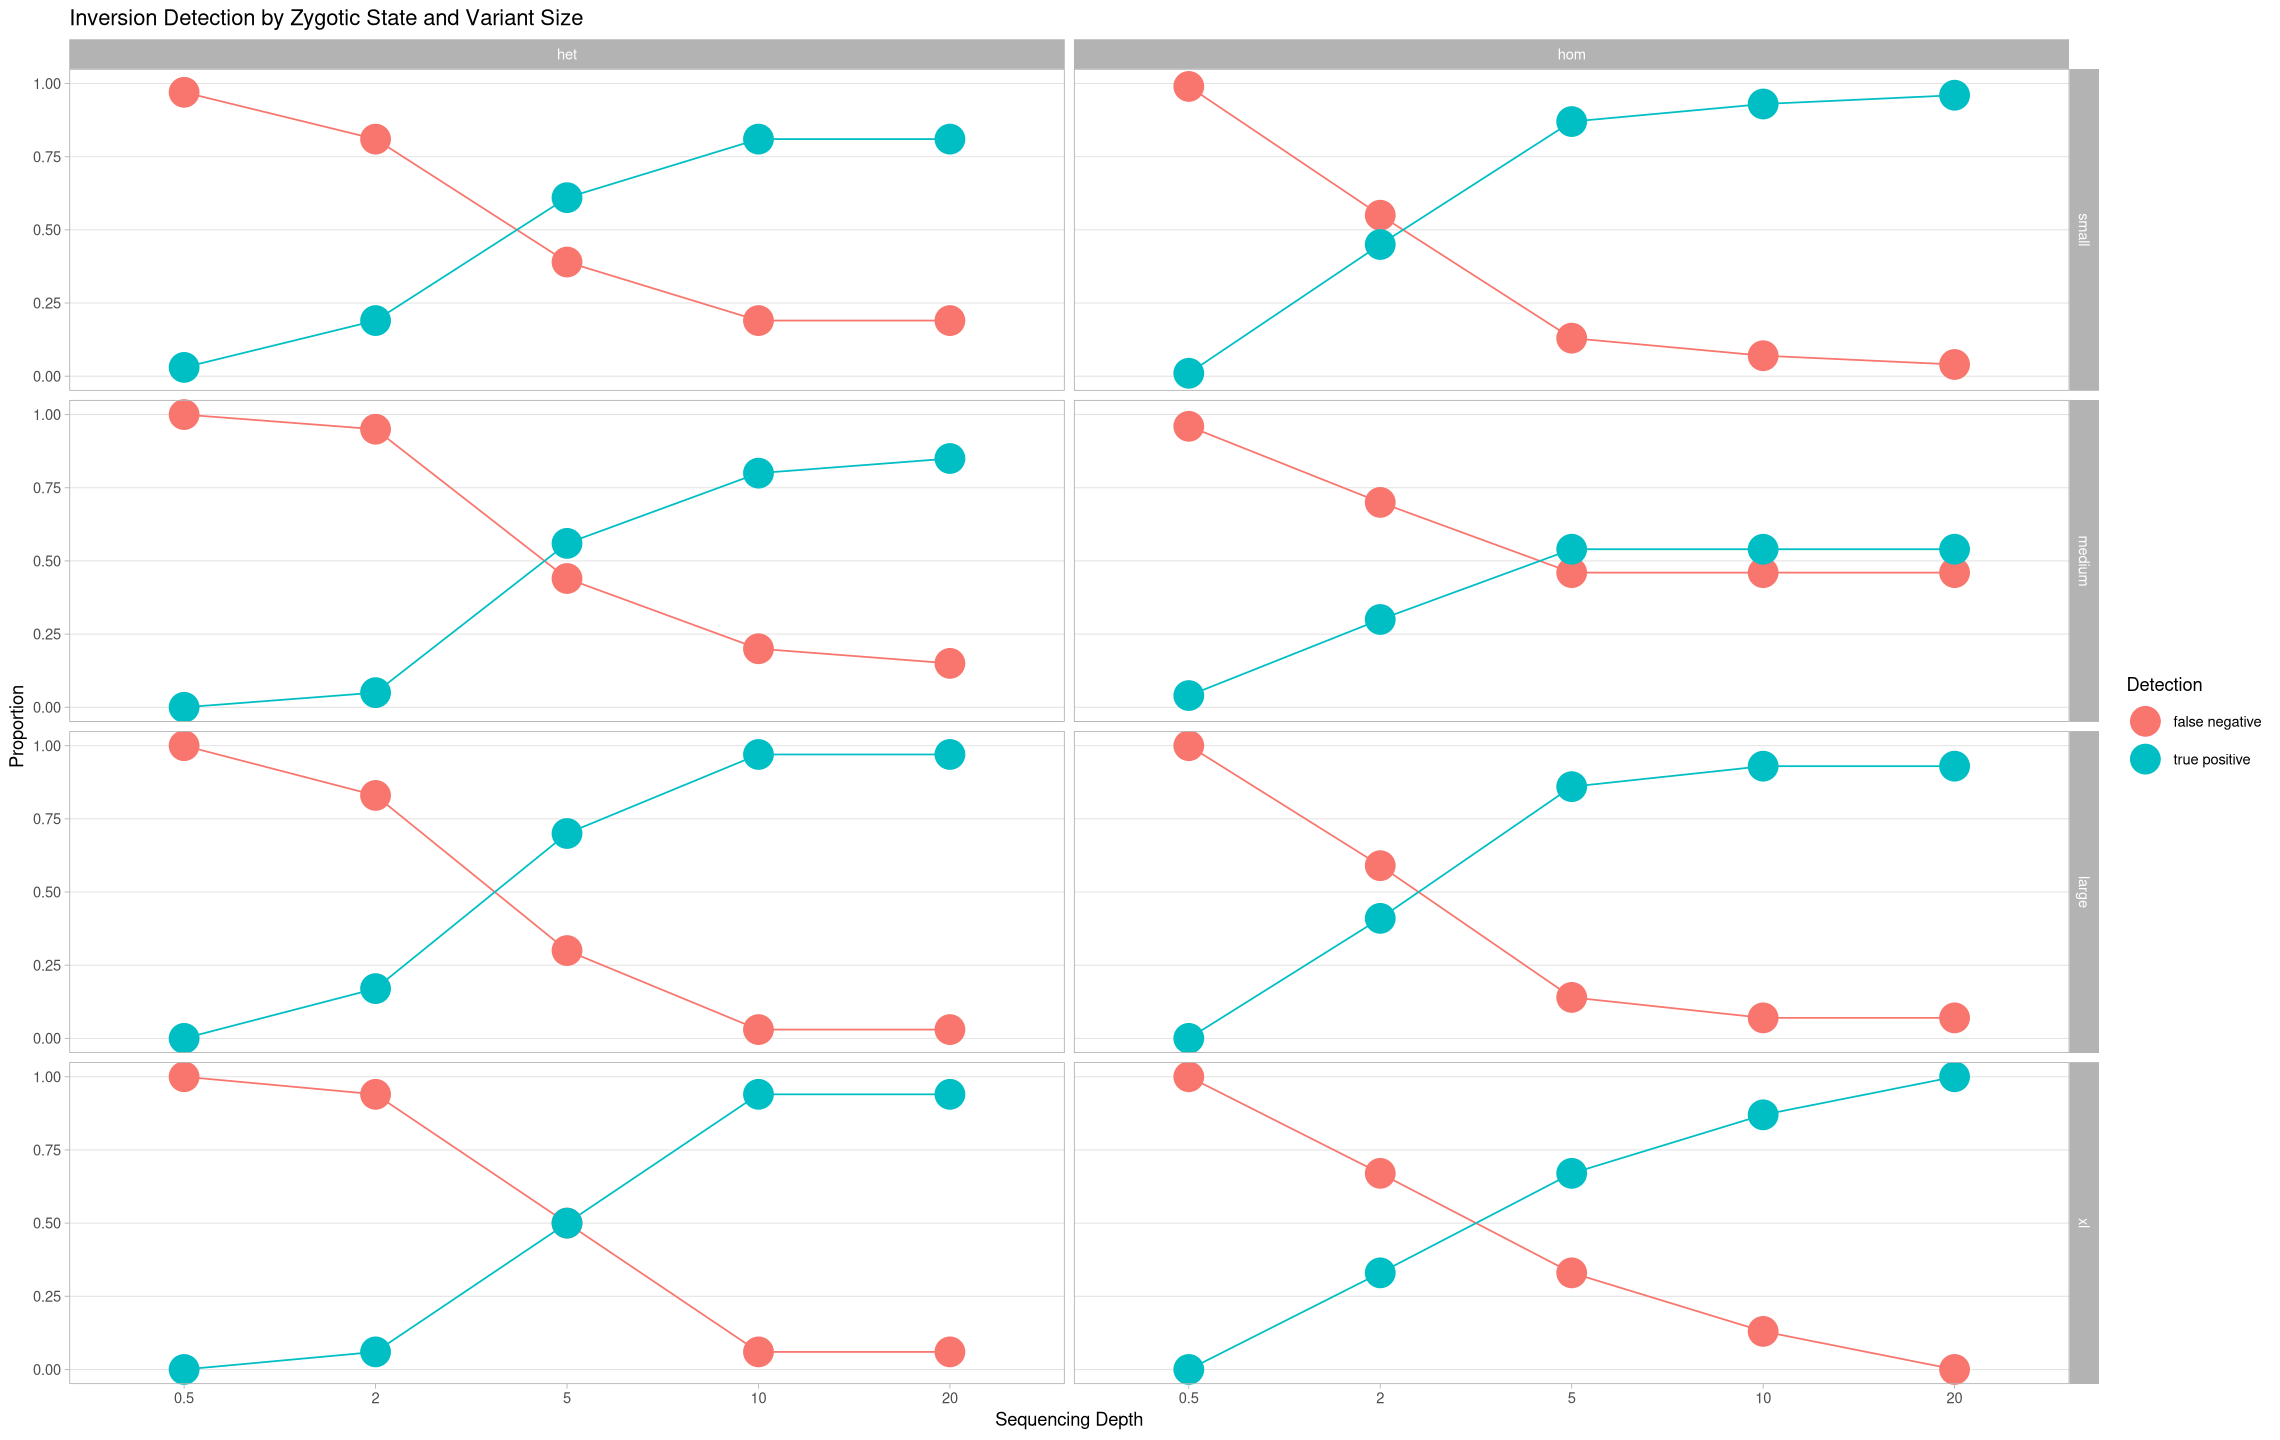

In [ ]:
ggplot(samples, aes(x = depth, y = proportion, color = state, group = state)) +
    geom_line() +
    geom_point(size = 8) +
    theme_light() +
    labs(title = "Inversion Detection by Zygotic State and Variant Size", color = "Detection") +
    ylab("Proportion") +
    xlab("Sequencing Depth") +
    theme(panel.grid.minor.y = element_blank(), panel.grid.major.x = element_blank()) +
    facet_grid(cols = vars(zygosity), rows = vars(size))

#### True Positives Across Depths
The proportions will always sum to `1`, so let's try a consolidated view where it's just the true positives across size treatments.

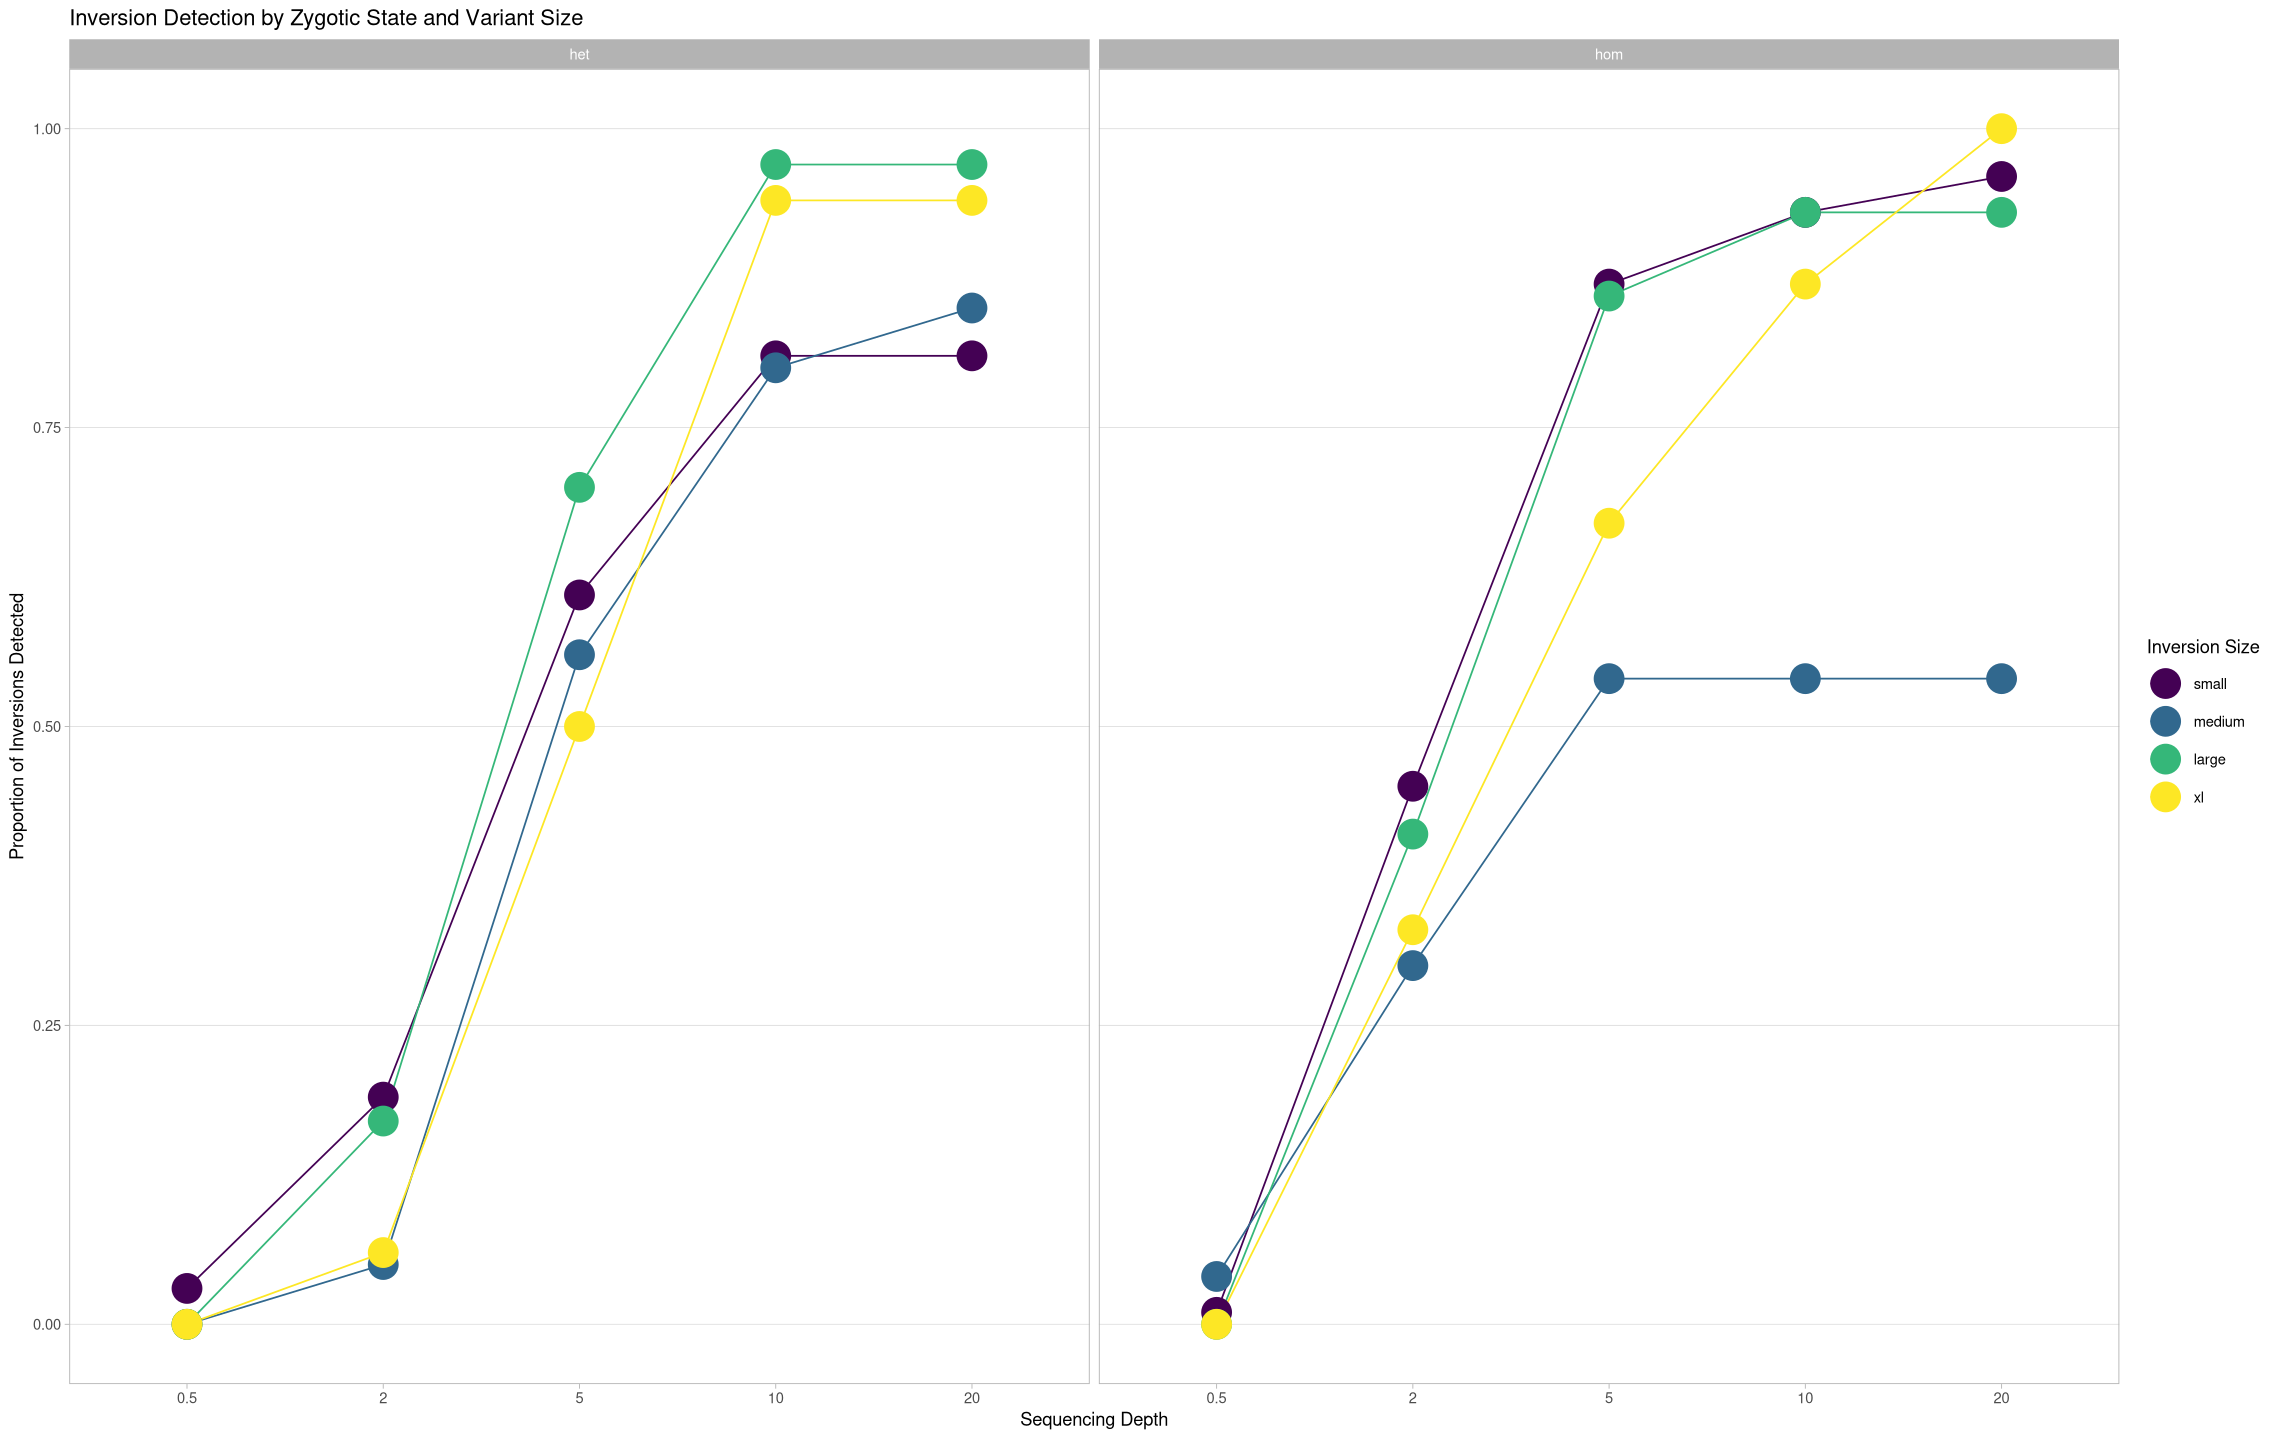

In [ ]:
ggplot(samples[samples$state == "true positive",], aes(x = depth, y = proportion, color = size, group = size)) +
    geom_line() +
    geom_point(size = 8) +
    theme_light() +
    labs(title = "Inversion Detection by Zygotic State and Variant Size", color = "Inversion Size") +
    ylab("Proportion of Inversions Detected") +
    xlab("Sequencing Depth") +
    theme(panel.grid.minor.y = element_blank(), panel.grid.major.x = element_blank()) +
    facet_grid(cols = vars(zygosity))

#### True Positives heterozygotic vs homozygotic
What about the change in performance between homozygotic and heterozygotic states?

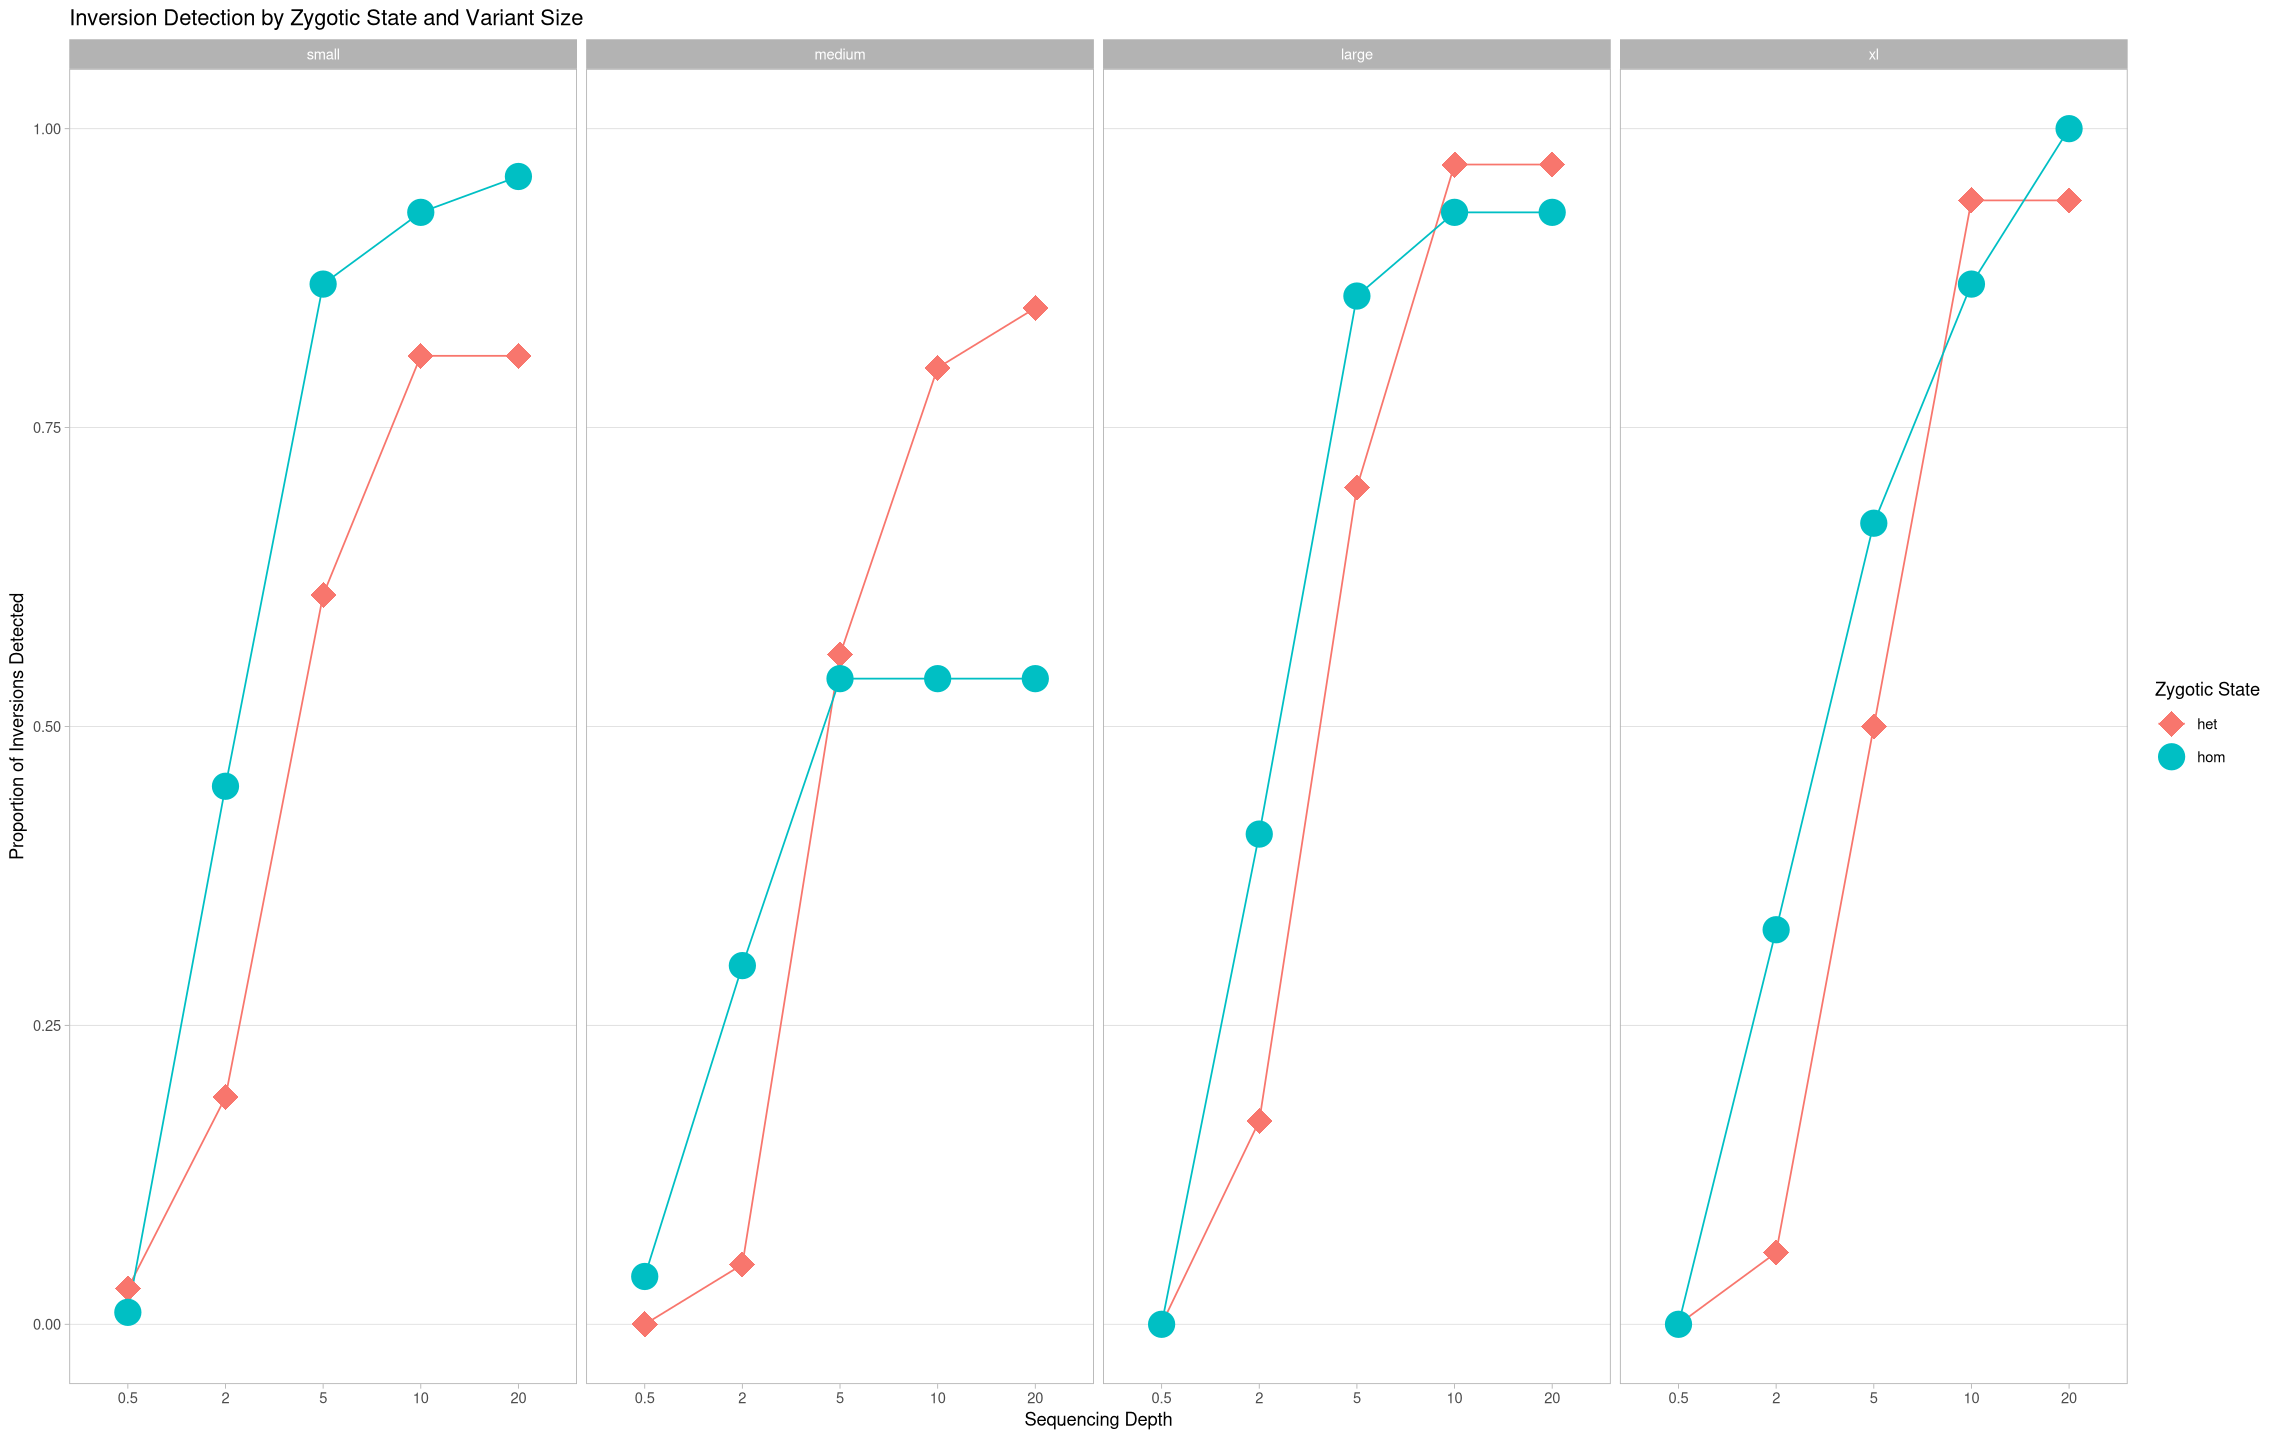

In [ ]:
ggplot(samples[samples$state == "true positive",], aes(x = depth, y = proportion, color = zygosity, group = zygosity)) +
    geom_line() +
    geom_point(aes(shape = zygosity), size = 7) +
    theme_light() +
    scale_shape_manual(values = c("hom"= 19,"het" = 18)) +
    labs(title = "Inversion Detection by Zygotic State and Variant Size", color = "Zygotic State", shape = "Zygotic State") +
    ylab("Proportion of Inversions Detected") +
    xlab("Sequencing Depth") +
    theme(panel.grid.minor.y = element_blank(), panel.grid.major.x = element_blank()) +
    facet_grid(cols = vars(size))

## Pooled Data
Now let's look at the analogous characteristics of the pooled data.

### Data Preparation
We need to filter for pooled samples only. The contig names don't matter so much here as much as "common" or "rare" does,
so we need to rename the contigs and sum their values. For plotting purporses, we'll also want to get a count of the number of inversions for each category so there's an indication of sample size for each treatment.

In [8]:
pooled <- assess[assess$sample == "pooled" & assess$simulated,]
pooled$treatment <- case_when(
    pooled$contig == "2L" ~ "Common",
    pooled$contig == "2R" ~ "Common",
    pooled$contig == "3L" ~ "Common",
    pooled$contig == "3R" ~ "Rare"
)

pooled <- group_by(pooled, treatment, size, depth, state) %>%
    summarize(count = n()) %>%
    group_by(treatment, size, depth) %>%
    mutate(total = sum(count))

head(pooled)

`summarise()` has grouped output by 'treatment', 'size', 'depth'. You can
override using the `.groups` argument.


treatment,size,depth,state,count,total
<chr>,<ord>,<fct>,<chr>,<int>,<int>
Common,small,0.5,false negative,8,15
Common,small,0.5,true positive,7,15
Common,small,2,false negative,6,15
Common,small,2,true positive,9,15
Common,small,5,false negative,5,15
Common,small,5,true positive,10,15


Again, some of the treatments are missing `false negative` or `true positive` rows, so we need to add them with a count of `0`.

In [9]:
# add missing rows with value 0 in the event there were no true positives or false negatives for a treatment
# instantiate empty def
missings <- pooled[0,]

for(size in c("small","medium","large","xl")){
    for(depth in levels(pooled$depth)){
        for(.treat in unique(pooled$treatment)){
            .df <- pooled[pooled$size == size & pooled$depth == depth & pooled$treatment == .treat,]
            .tot <- sum(.df$total)
            if(!("false negative" %in% .df$state)){
                missings[nrow(missings)+1,] <- list(.treat, size, depth, "false negative", 0, .tot)
            }
            if(!("true positive" %in% .df$state)){
                missings[nrow(missings)+1,] <- list(.treat, size, depth, "true positive", 0, .tot)
            }
        }
    }
}

pooled <- rbind(pooled,missings) %>% arrange(treatment, size, depth)
head(pooled)

treatment,size,depth,state,count,total
<chr>,<ord>,<fct>,<chr>,<int>,<int>
Common,small,0.5,false negative,8,15
Common,small,0.5,true positive,7,15
Common,small,2,false negative,6,15
Common,small,2,true positive,9,15
Common,small,5,false negative,5,15
Common,small,5,true positive,10,15


Lastly, convert the counts to proportions. Let's also rename the depths to properly reflect that with aggregates, the depth is actually 10X higher. Seems silly to have to do `as.numeric(as.character())`, but if you don't convert it to a `Character` first, `0.5` gets misinterpereted as `1`.

In [10]:
pooled <- group_by(pooled, treatment, size, depth) %>% mutate(proportion = round(count/sum(count),2))
agg_depths <- paste0(as.numeric(as.character(pooled$depth)) * 10, " (", pooled$depth, ")")
pooled$agg_depth <- factor(agg_depths, levels = unique(agg_depths))
head(pooled)

treatment,size,depth,state,count,total,proportion,agg_depth
<chr>,<ord>,<fct>,<chr>,<int>,<int>,<dbl>,<fct>
Common,small,0.5,false negative,8,15,0.53,5 (0.5)
Common,small,0.5,true positive,7,15,0.47,5 (0.5)
Common,small,2,false negative,6,15,0.40,20 (2)
Common,small,2,true positive,9,15,0.60,20 (2)
Common,small,5,false negative,5,15,0.33,50 (5)
Common,small,5,true positive,10,15,0.67,50 (5)


### Plotting
#### True Positives vs False Negatives

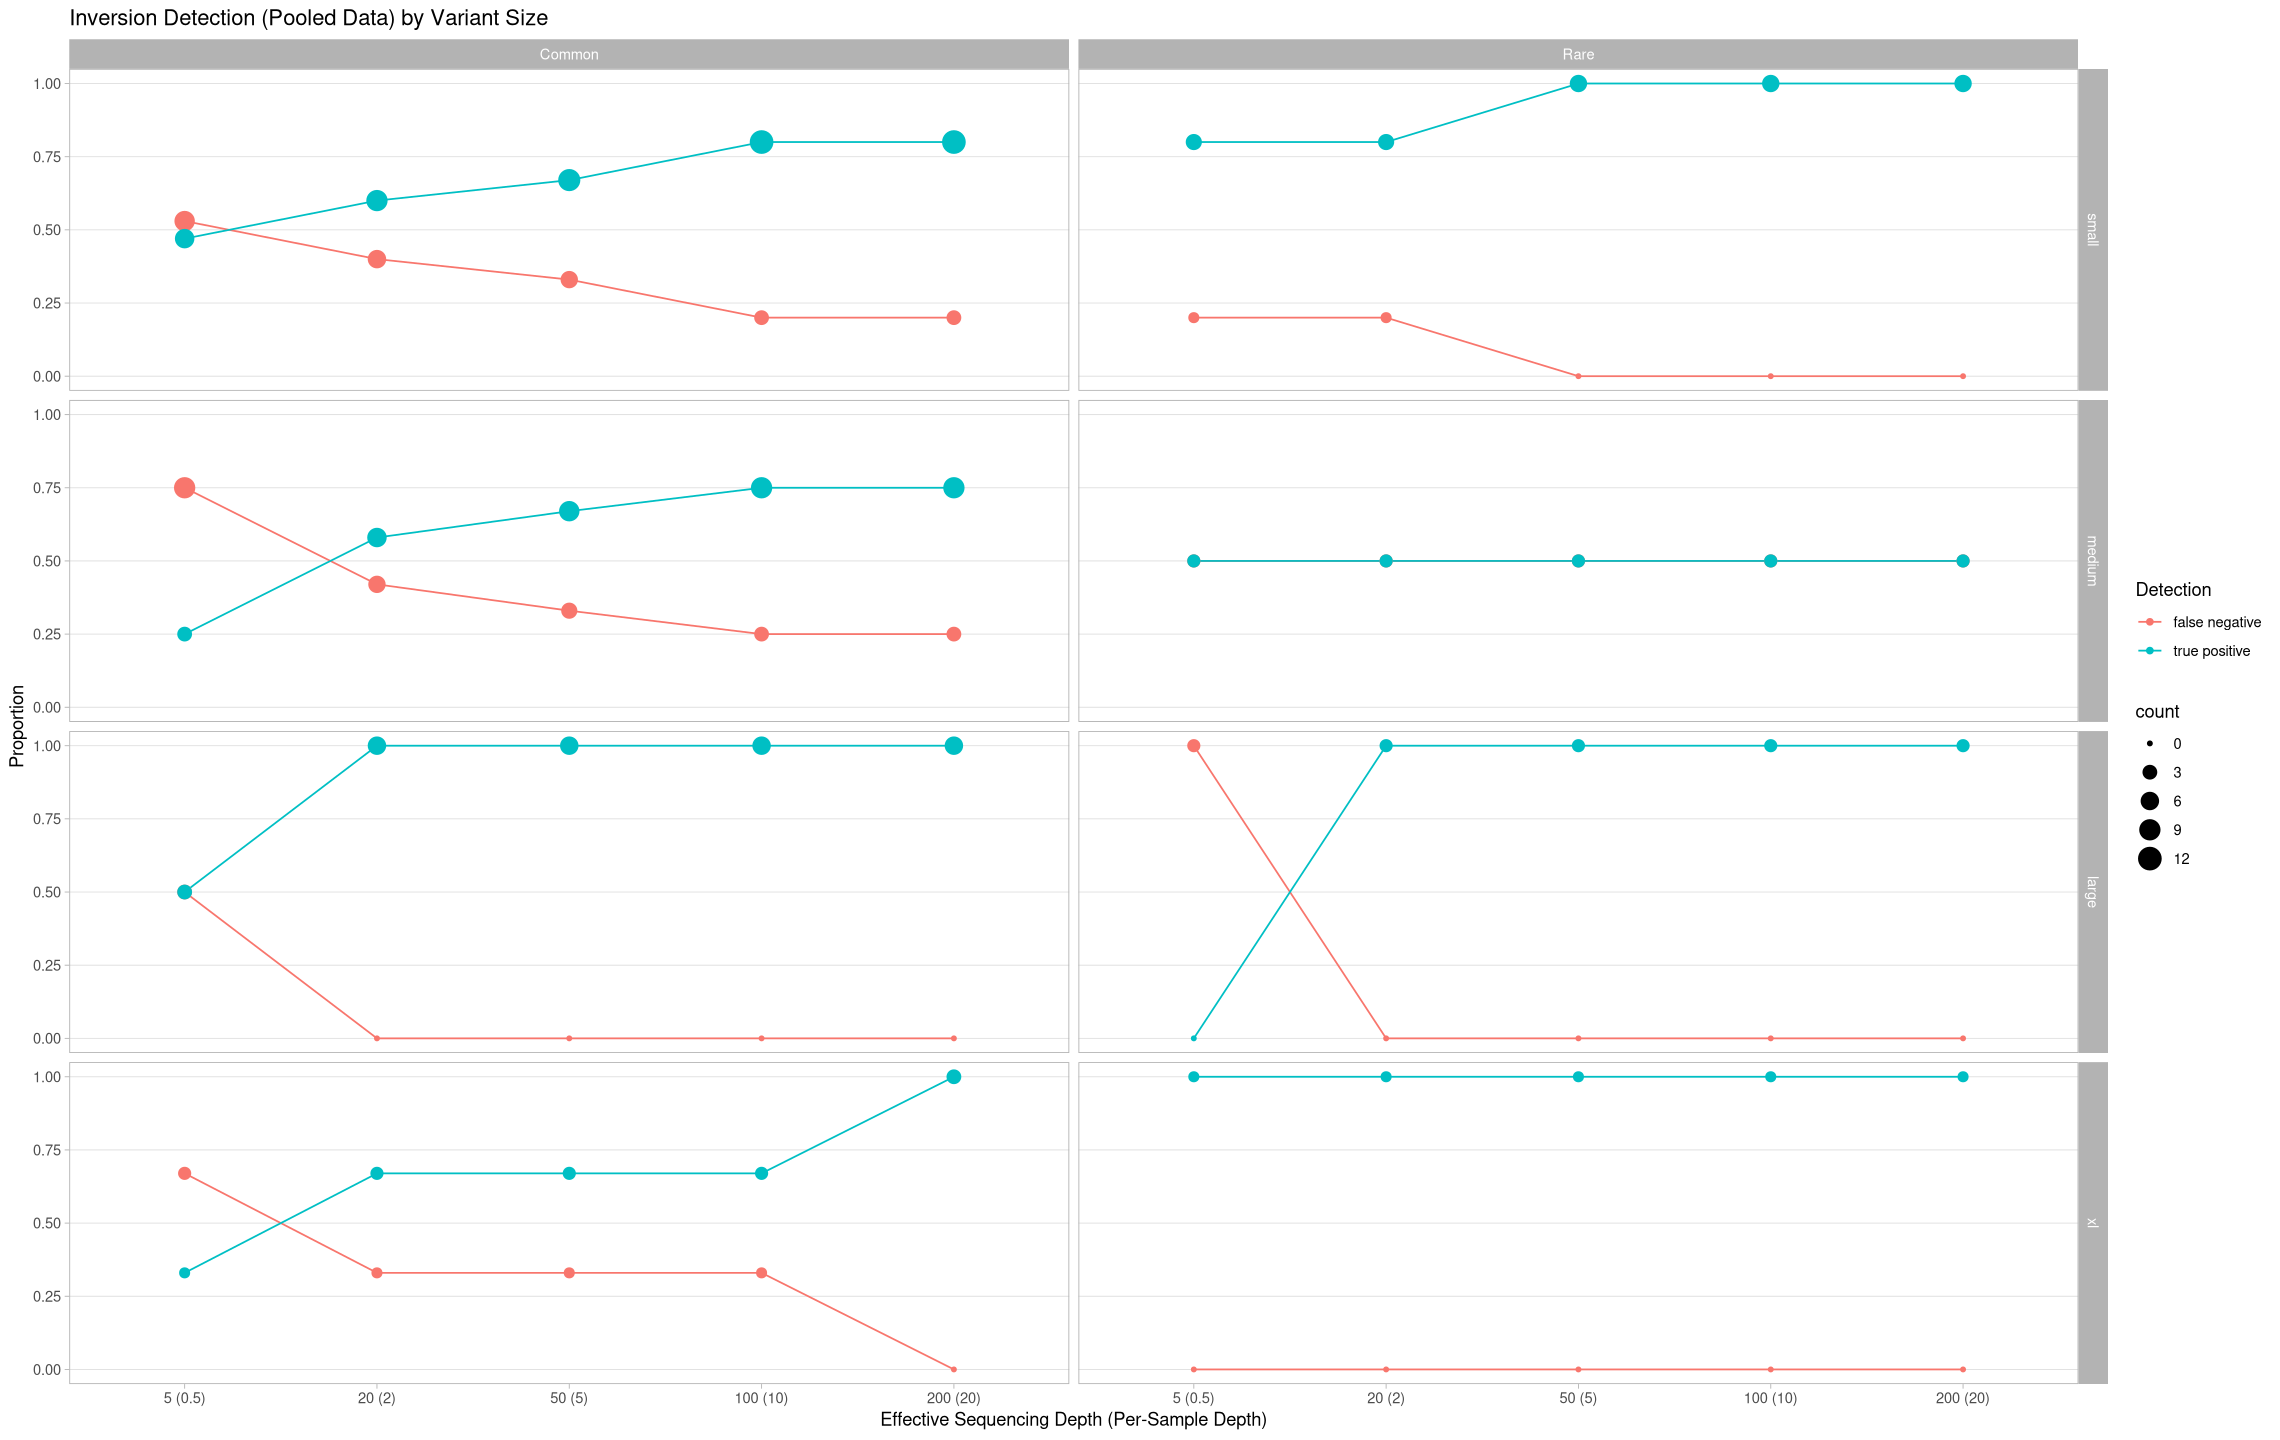

In [ ]:
ggplot(pooled, aes(x = agg_depth, y = proportion, color = state, group = state)) +
    geom_line() +
    geom_point(aes(size = count)) +
    theme_light() +
    labs(title = "Inversion Detection (Pooled Data) by Variant Size", color = "Detection") +
    ylab("Proportion") +
    xlab("Effective Sequencing Depth (Per-Sample Depth)") +
    theme(panel.grid.minor.y = element_blank(), panel.grid.major.x = element_blank()) +
    facet_grid(cols = vars(treatment), rows = vars(size))

#### True Positives Across Inversion Size Classes
Consolidate views of just true positives across treatments

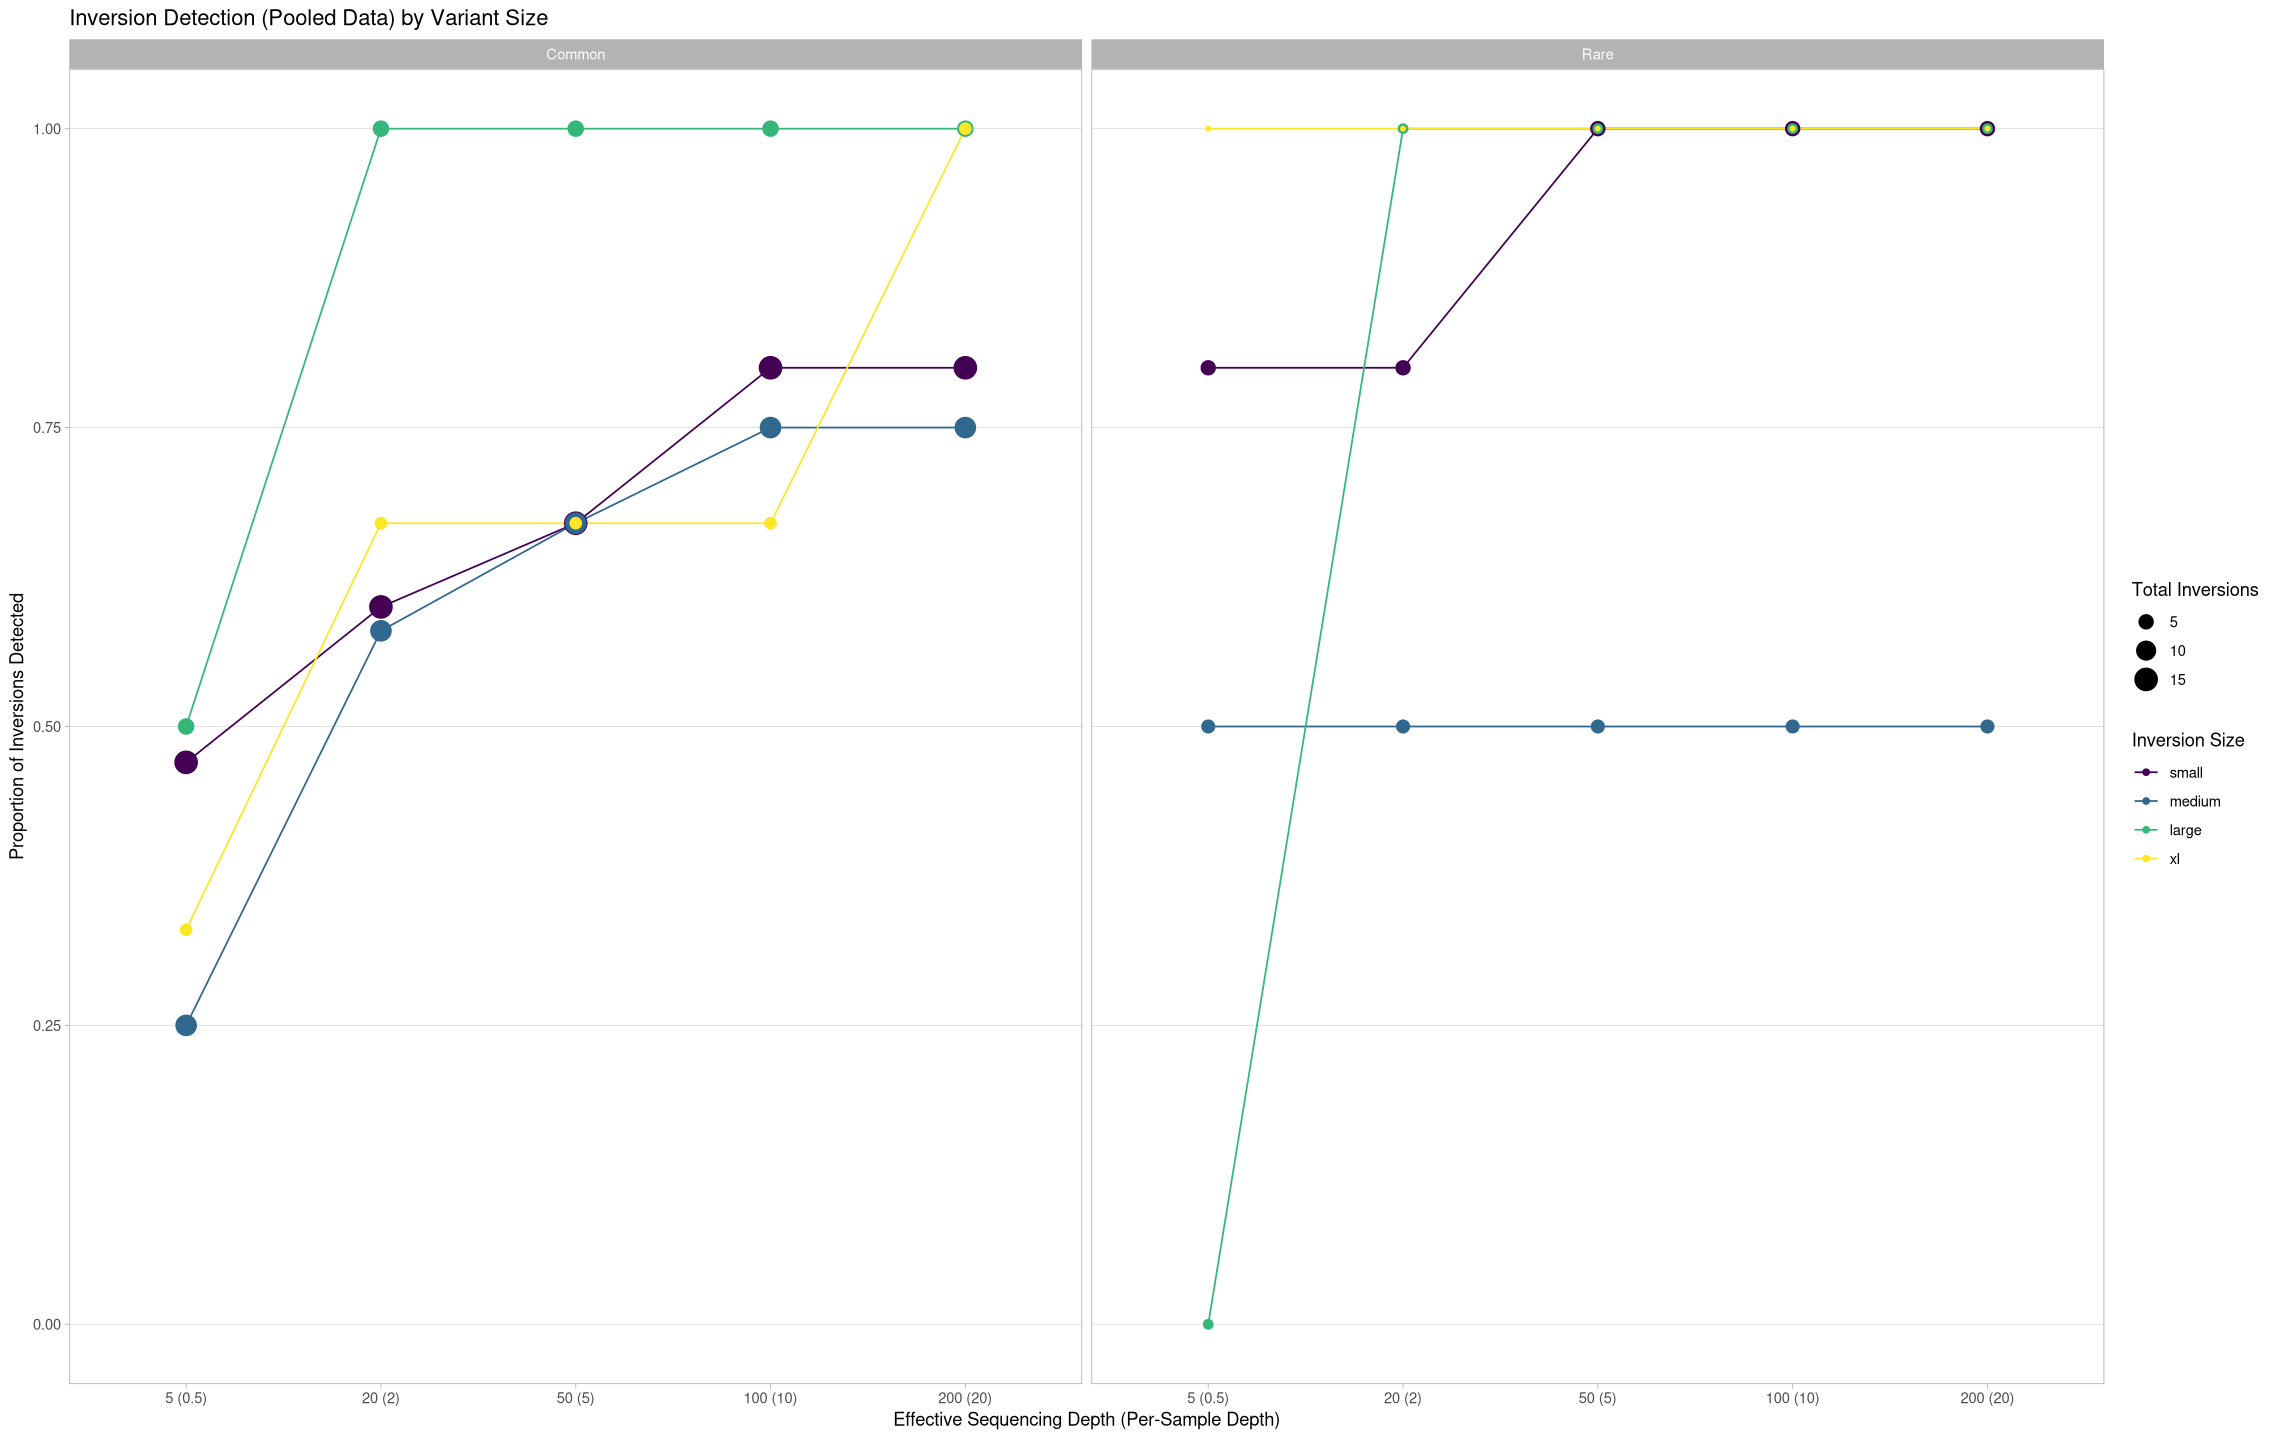

In [60]:
ggplot(pooled[pooled$state == "true positive",], aes(x = agg_depth, y = proportion, color = size, group = size)) +
    geom_line() +
    geom_point(aes(size = total)) +
    theme_light() +
    labs(title = "Inversion Detection (Pooled Data) by Variant Size", color = "Inversion Size", size = "Total Inversions") +
    ylab("Proportion of Inversions Detected") +
    xlab("Effective Sequencing Depth (Per-Sample Depth)") +
    theme(panel.grid.minor.y = element_blank(), panel.grid.major.x = element_blank()) +
    facet_grid(cols = vars(treatment))

#### True Positives Across Inversion Frequency in a Population
What about the change in performance between contigs?

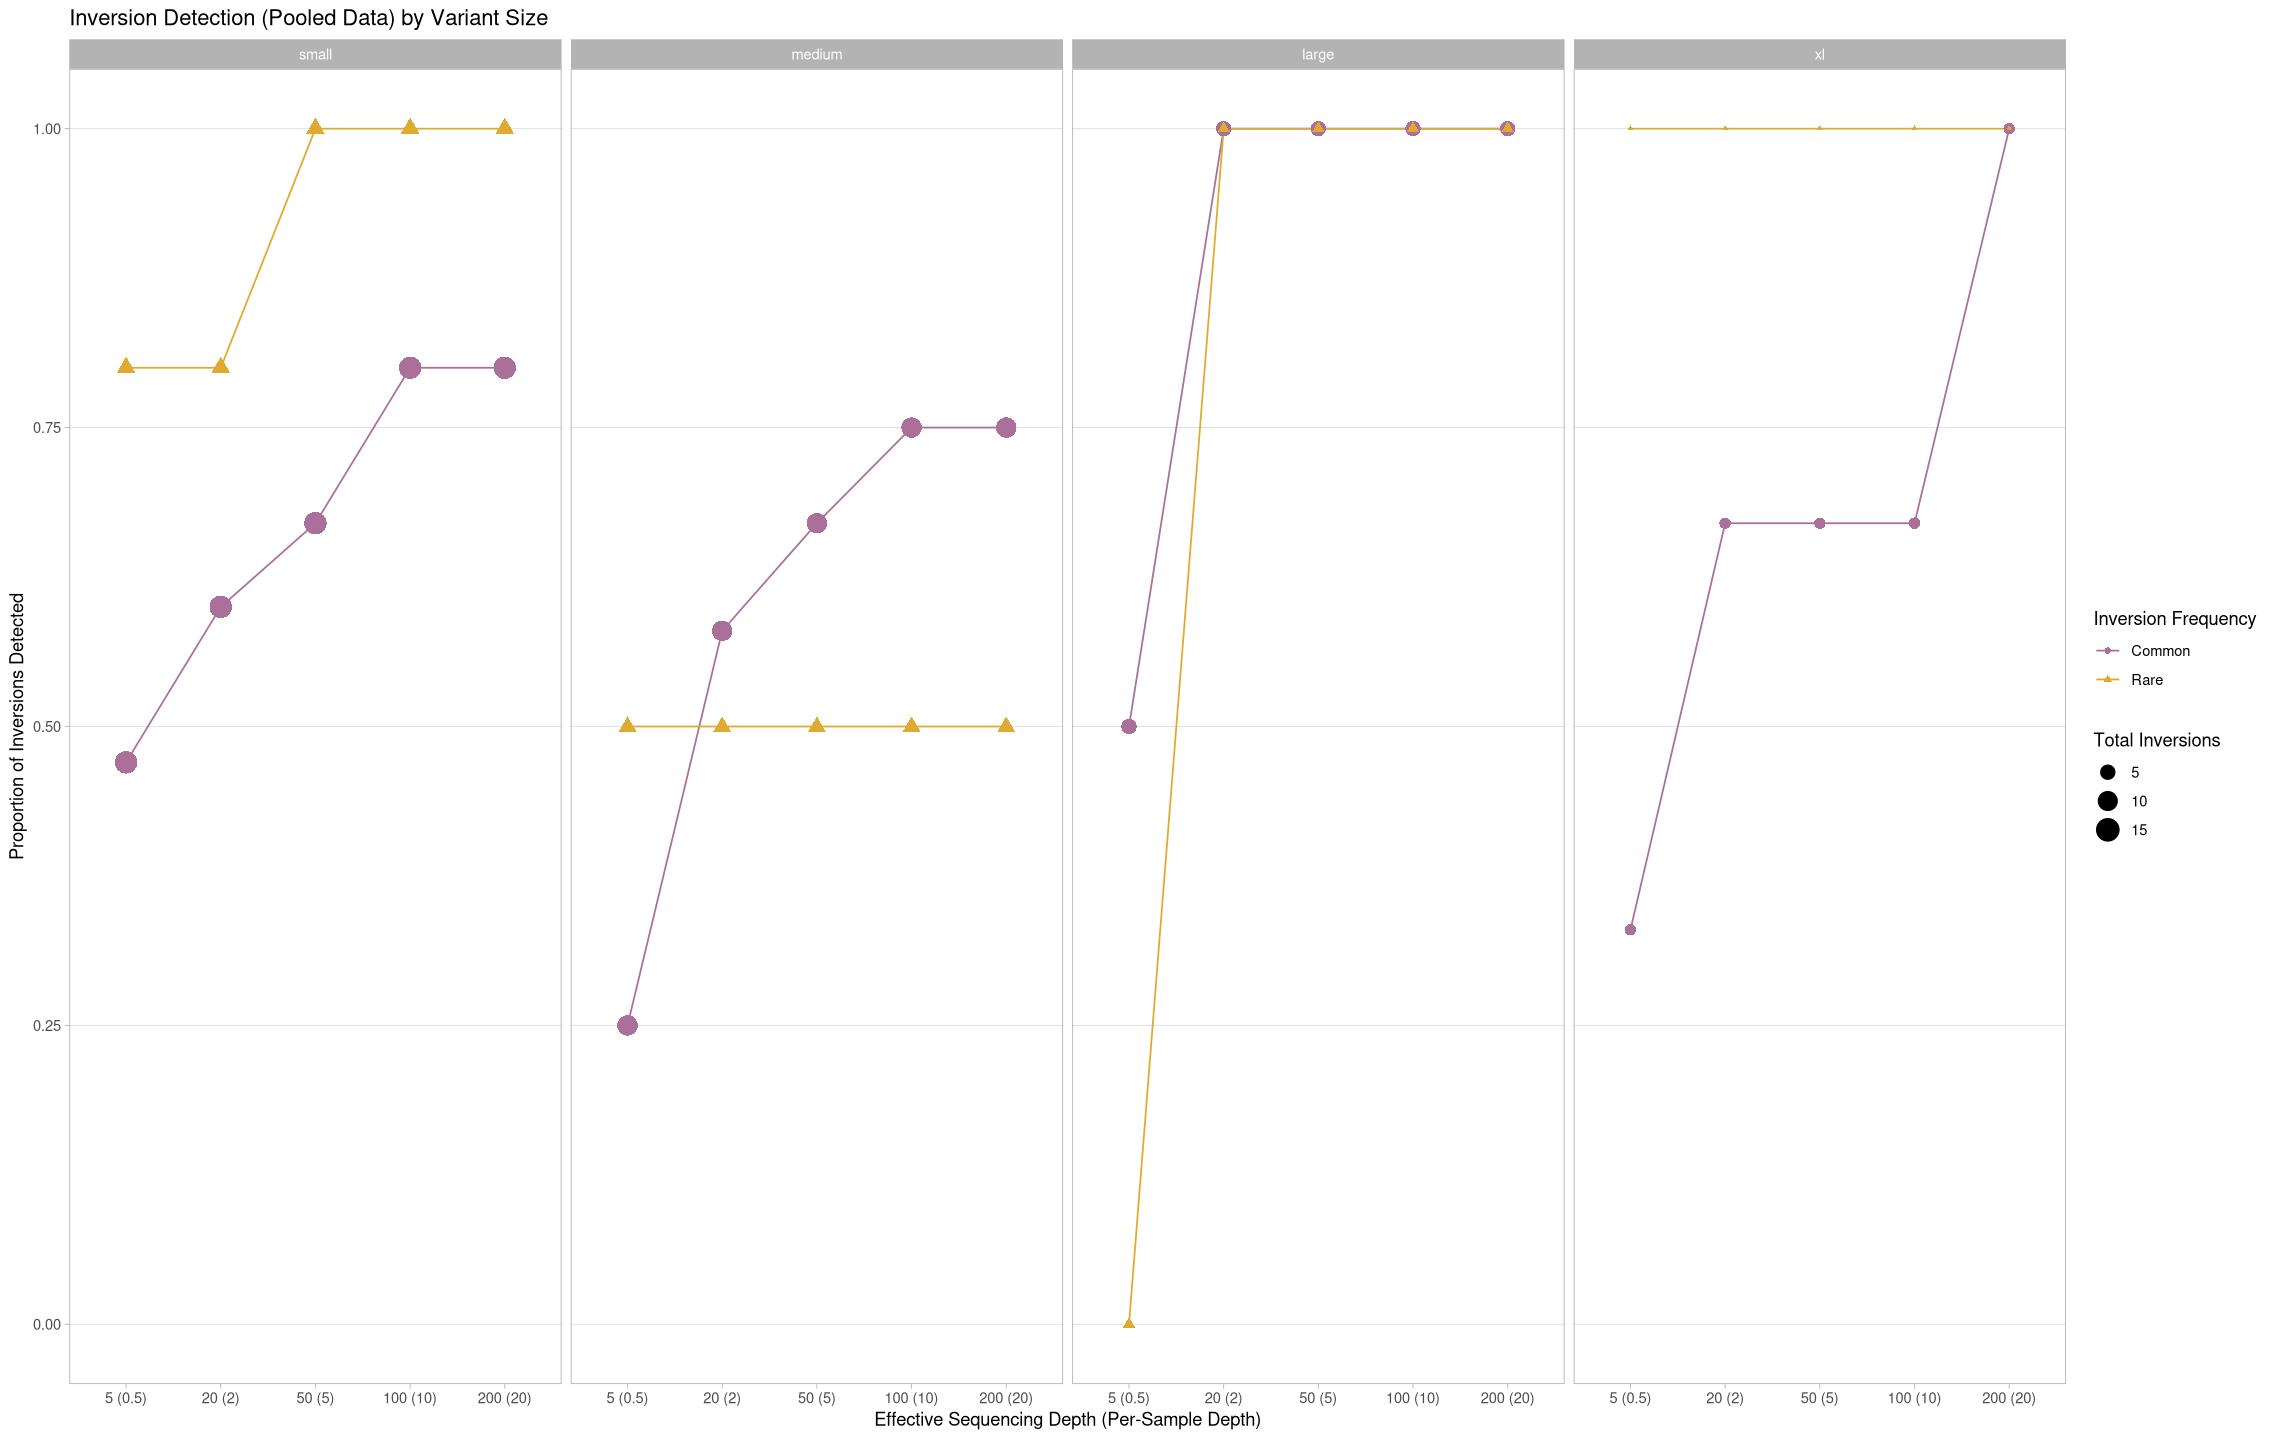

In [68]:
ggplot(pooled[pooled$state == "true positive",], aes(x = agg_depth, y = proportion, color = treatment, group = treatment)) +
    geom_line() +
    geom_point(aes(shape = treatment, size = total)) +
    theme_light() +
    scale_color_manual(values = c("Common"= "#aa7099", "Rare" = "#e0aa30")) +
    labs(title = "Inversion Detection (Pooled Data) by Variant Size", color = "Inversion Frequency", shape = "Inversion Frequency", size = "Total Inversions") +
    ylab("Proportion of Inversions Detected") +
    xlab("Effective Sequencing Depth (Per-Sample Depth)") +
    theme(panel.grid.minor.y = element_blank(), panel.grid.major.x = element_blank()) +
    facet_grid(cols = vars(size))

What if we look at it over the number of inversions present in a pool?

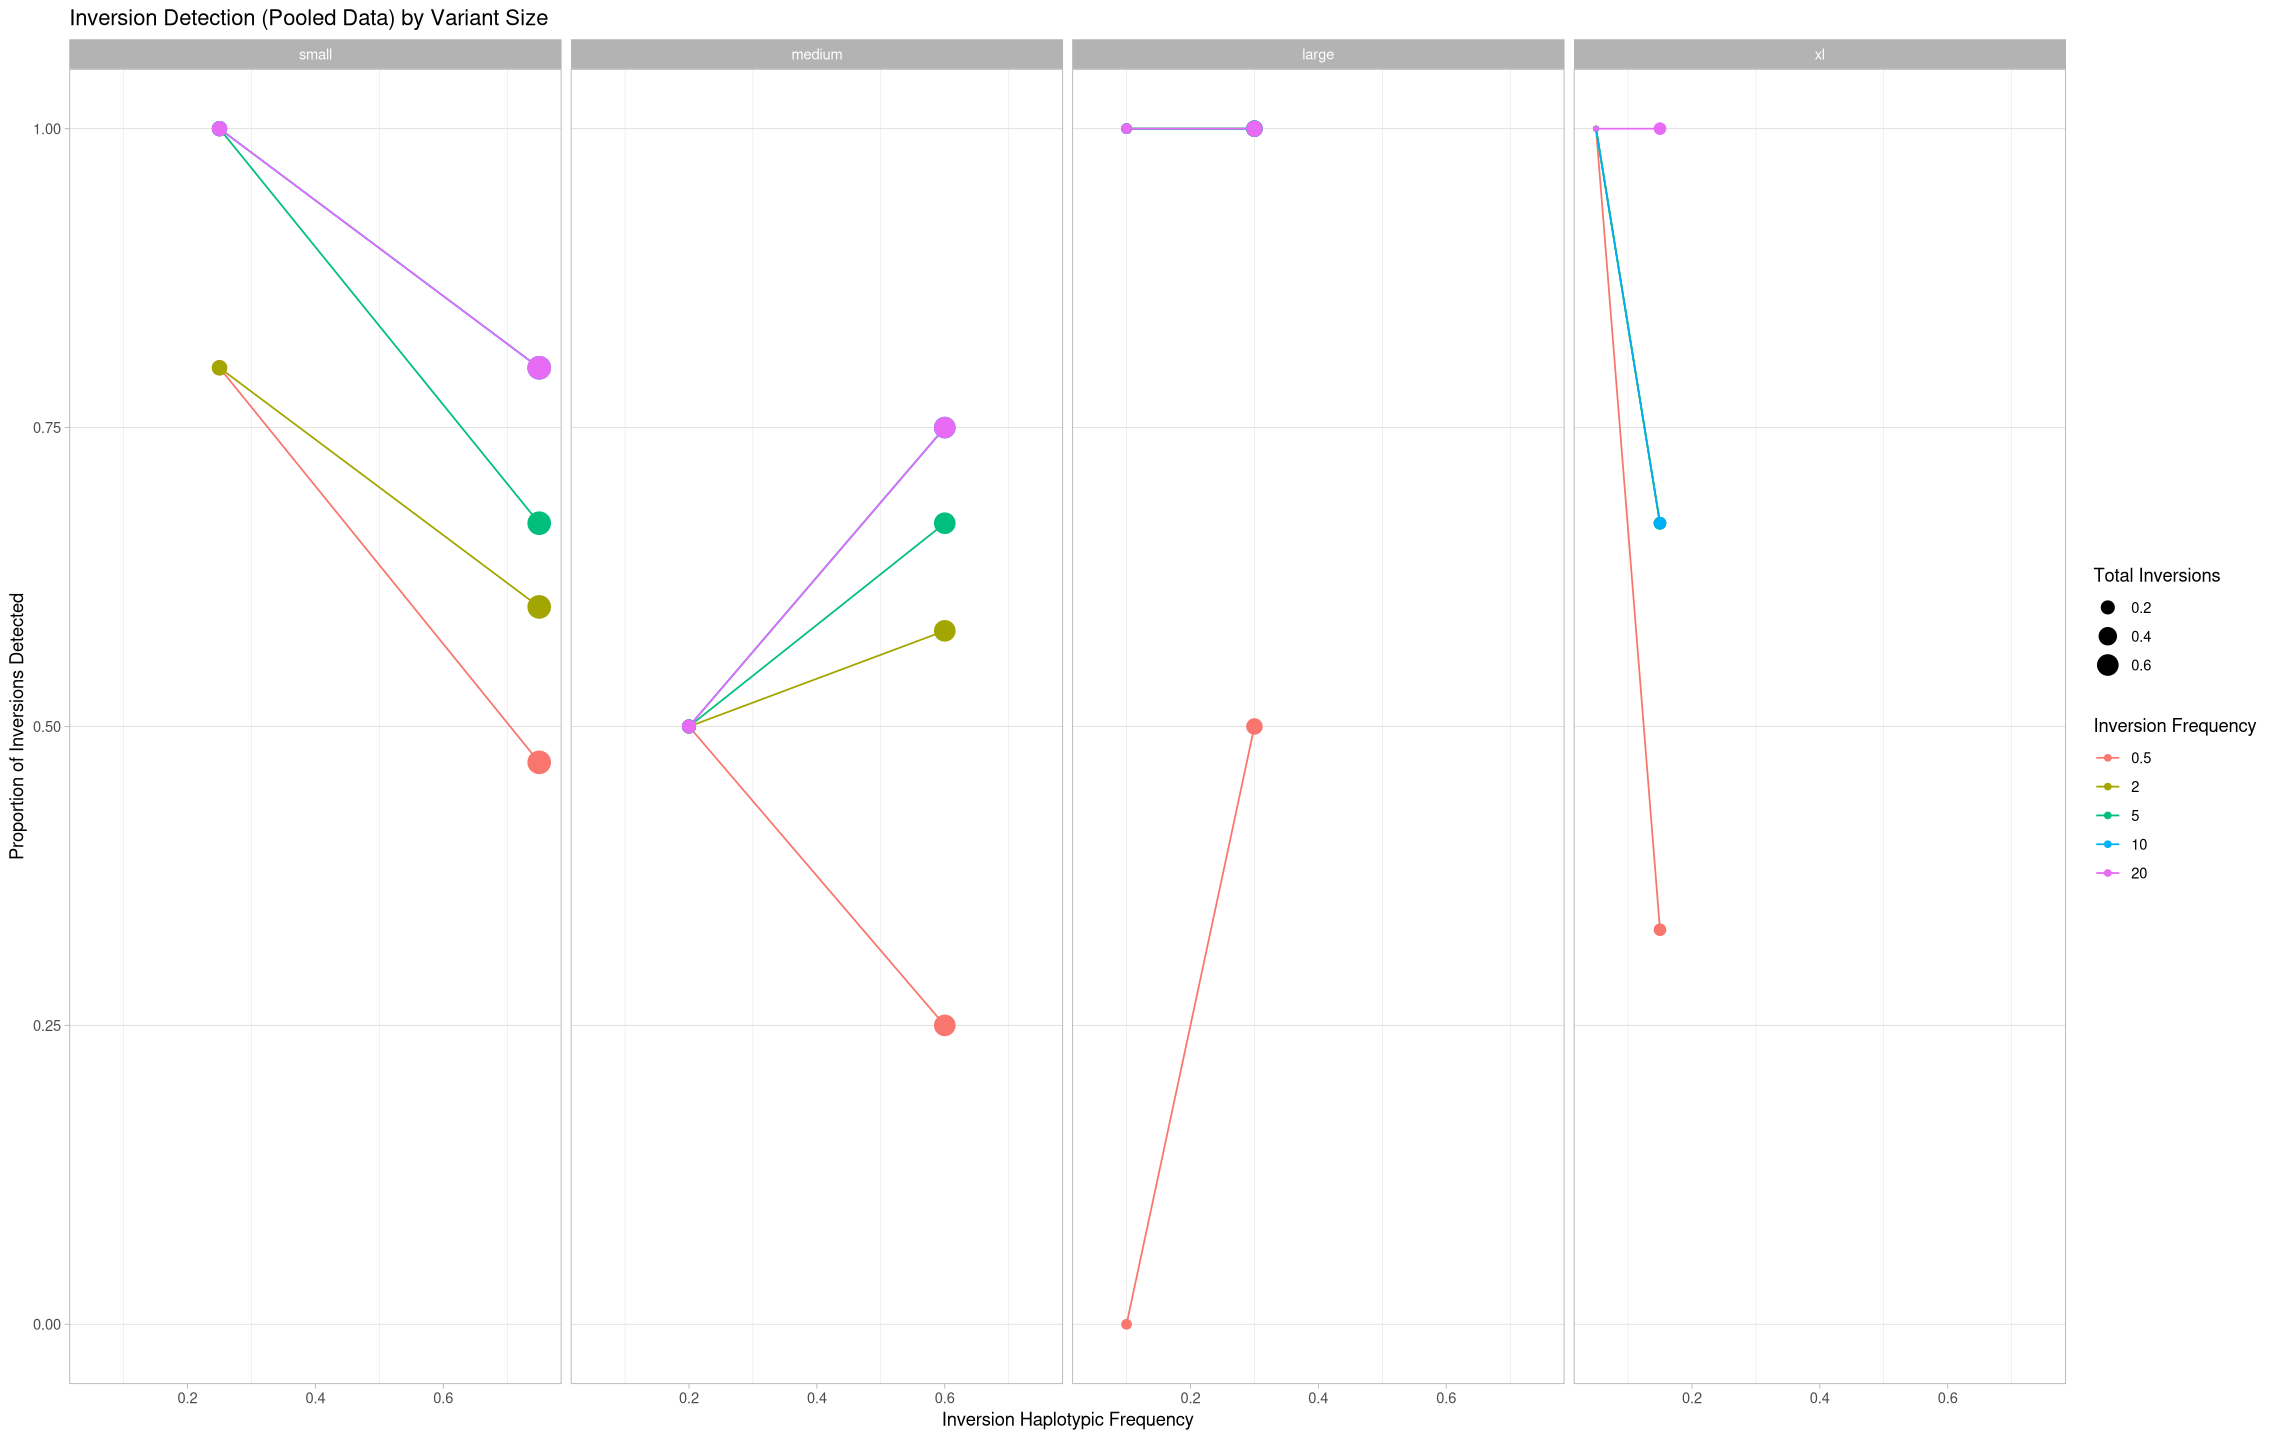

In [ ]:
ggplot(pooled[pooled$state == "true positive",], aes(x = total/20, y = proportion, color = depth, group = depth)) +
    geom_line() +
    geom_point(aes(size = total/20)) +
    theme_light() +
    #scale_color_manual(values = c("Common"= "#aa7099", "Rare" = "#e0aa30")) +
    labs(title = "Inversion Detection (Pooled Data) by Variant Size", color = "Inversion Frequency", shape = "Inversion Frequency", size = "Total Inversions") +
    ylab("Proportion of Inversions Detected") +
    xlab("Inversion Haplotypic Frequency") +
    theme(panel.grid.minor.y = element_blank(), panel.grid.major.x = element_blank()) +
    facet_grid(cols = vars(size))